<a href="https://colab.research.google.com/github/AbhishekRReddy/AbhishekRReddy/blob/main/Group_22_APL7000_Ranking_an_IPL_Team.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#`Group 22`
##Abhishek R Reddy - 2025AMA2244
##Nitin Kumar - 2025AMA2234
##Vivek Parmar - 2025AMA2219

--------------------------------------------------------------------------------

#**Ranking an IPL team**

###Problem with Current IPL Rankings system or Points Table
* It considers only win or loss method.
* Rewards teams for simply winning, regardless of opponent quality.
* A simple ranking based on points.
* It does not consider the margin of win in the match.

If we see this is not ideal way to judge a team. We need a better system to judge the team based on thier strength not just by mere win or loss.


###**<ins>Massey's Method</ins>**

$r_i - r_j = Point \ Difference$  

We know the match scores between two individual team. So we can calculate the difference between the scores x - y = point difference.

Suppose, if there are 10 times and if each team play against other, then there will be 9 matches data played be a single team. So each team will have 9 data points of the point difference.

####**<ins>Creating Matrix $P$ </ins>**

We are creating win loss matrix, each row represents a match and columns contains all the teams. The columns are uniquely assigned to each team. Team which has won will get '1' and team which has lost will get '-1' under its column. So under each row, we will be having 1 and -1 against the teams which have played the match and 0 everywhere as those teams aren't involved.  

####**<ins>Governing Equation</ins>**
$PR = B$.

$P$ is the above matrix we created which contains win (+1) or loss (-1).  

$R$ is n x 1 column vector where each row contains the rank of the each team, where n is the number of teams.

$B$ is the m x 1 is the point differential of each game.

####**<ins>Case of the Overdetermined Equations**
When we have more equations than the number of unknowns (here n unknowns of Column Matrix R i.e we need rank of each team) then it leads to case of overdetermined equation and solution is impossible to findout.

This is arising due to the fact that there will be definitely more number of matches in any tournament than that number of teams actually playing.

Hence instead of solving this system of linear equation  exactly we search for vector R which satisfies the system as close as possible. This can be achieved by least squares method where we try to find vector R which minimizes the vector norm of $|| PR - B ||$ . This is equivalent to solving the system of linear equations $P^TPR = P^TB$

Now we need to solve for vector $R$.

Let's replace, $P^TP$ with $M$ and $P^TB$ with $Q$.

Now this $M_{ii}$ contains number of matches played by $i^{th}$ team.

$M_{ij}$ contains the negation of number of matches played between $i^{th}$ and $j^{th}$ team. It can be more than 1 match also. If the number of matched played between ith and jth team is 3 then that particular element contains $-3$

Equation becomes
$MR = Q$

Now all the Matrices have same number of row, by solving for R we get n unique solutions as rankings of each team.

####**<ins>Problem with M</ins>**
After a few matches, this Matrix $M$ becomes a rank of (n-1) which leads to no solution as the rank of the matrix M will be less than the rank of the augmented matrix.

To fix the this we are making last row of $M$ as  1. The last row of the $Q$ as 0. Then rank of co-efficient matrix and augmented matrix = number of unknown. Hence we will get the unique rankings for all the team.

Now just solve for the Q. Each row contains the corresponding teams ranking.


####**<ins>Regarding Point Differential</ins>**
* The point differential for winning by runs can be written as runs difference divided by the first innings score.
* Whereas for winning by wickets it can be written as wicket difference divided by 10.
* Only magnitude is considered.


In [89]:
# Downloaoding the IPL Dataset from Kaggle using the Kaggle Module
import kagglehub

# Download latest version
path = kagglehub.dataset_download("patrickb1912/ipl-complete-dataset-20082020")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ipl-complete-dataset-20082020' dataset.
Path to dataset files: /kaggle/input/ipl-complete-dataset-20082020


In [90]:
import pandas as pd
import numpy as np

ipl_dataset = pd.read_csv(path + "/matches.csv")

#To check how the csv data looks like
ipl_dataset.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [91]:
#Choosing only data for 2024 season
ipl_2024 = ipl_dataset[ipl_dataset["season"] =='2024']
ipl_2024.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
1024,1422119,2024,Chennai,2024-03-22,League,Mustafizur Rahman,"MA Chidambaram Stadium, Chepauk, Chennai",Royal Challengers Bengaluru,Chennai Super Kings,Royal Challengers Bengaluru,bat,Chennai Super Kings,wickets,6.0,174.0,20.0,N,NaN,HAS Khalid,VK Sharma
1025,1422120,2024,Mohali,2024-03-23,League,SM Curran,Maharaja Yadavindra Singh International Cricke...,Delhi Capitals,Punjab Kings,Punjab Kings,field,Punjab Kings,wickets,4.0,175.0,20.0,N,NaN,J Madanagopal,NA Patwardhan
1026,1422121,2024,Kolkata,2024-03-23,League,AD Russell,"Eden Gardens, Kolkata",Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Kolkata Knight Riders,runs,4.0,209.0,20.0,N,NaN,R Pandit,YC Barde
1027,1422122,2024,Jaipur,2024-03-24,League,SV Samson,"Sawai Mansingh Stadium, Jaipur",Rajasthan Royals,Lucknow Super Giants,Rajasthan Royals,bat,Rajasthan Royals,runs,20.0,194.0,20.0,N,NaN,A Totre,HDPK Dharmasena
1028,1422123,2024,Ahmedabad,2024-03-24,League,B Sai Sudharsan,"Narendra Modi Stadium, Ahmedabad",Gujarat Titans,Mumbai Indians,Mumbai Indians,field,Gujarat Titans,runs,6.0,169.0,20.0,N,NaN,VA Kulkarni,VK Sharma


In [92]:
#Confirming if there are any super over matches happened in IPL2024 season
ipl_2024[ipl_2024['super_over'] != 'N']

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2


In [93]:
#Choosing the relevant columns which are needed for ranking of an IPL Team
match_data = ipl_2024[["team1",'team2','winner','result','result_margin','target_runs','city']]
match_data.head()

,team1,team2,winner,result,result_margin,target_runs,city
1024,Royal Challengers Bengaluru,Chennai Super Kings,Chennai Super Kings,wickets,6.0,174.0,Chennai
1025,Delhi Capitals,Punjab Kings,Punjab Kings,wickets,4.0,175.0,Mohali
1026,Kolkata Knight Riders,Sunrisers Hyderabad,Kolkata Knight Riders,runs,4.0,209.0,Kolkata
1027,Rajasthan Royals,Lucknow Super Giants,Rajasthan Royals,runs,20.0,194.0,Jaipur
1028,Gujarat Titans,Mumbai Indians,Gujarat Titans,runs,6.0,169.0,Ahmedabad


In [94]:
#Resetting the index
match_data = match_data.reset_index(drop = True)
match_data.head()

,team1,team2,winner,result,result_margin,target_runs,city
0,Royal Challengers Bengaluru,Chennai Super Kings,Chennai Super Kings,wickets,6.0,174.0,Chennai
1,Delhi Capitals,Punjab Kings,Punjab Kings,wickets,4.0,175.0,Mohali
2,Kolkata Knight Riders,Sunrisers Hyderabad,Kolkata Knight Riders,runs,4.0,209.0,Kolkata
3,Rajasthan Royals,Lucknow Super Giants,Rajasthan Royals,runs,20.0,194.0,Jaipur
4,Gujarat Titans,Mumbai Indians,Gujarat Titans,runs,6.0,169.0,Ahmedabad


In [95]:
#Calculating the number of matches happened in the IPL season of 2024
print(len(match_data))
#This will acts as number of rows in Matrix P

71


In [96]:
#Calculating the number of teams played in IPL 2024
print('Number of Teams Played in IPL 2024: '+ str(len(match_data['team1'].unique())))

Number of Teams Played in IPL 2024: 10


In [97]:
#Constructing the matrix P with all zero
P = np.zeros((71,10))
print(P.shape)
print(P)

(71, 10)
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 

In [98]:
#Constructing the matrix B with all zero
#B Contains 71 rows and 1 column to store
B = np.zeros((71))
print(B.shape)

(71,)


In [99]:
#Constructing the matrix R which will contains the rank of each team
#Initially assigning all the rows to 0
R = np.zeros((10))
R.shape

(10,)

In [100]:
#Assigning a unique team number to each teams played
teams = match_data['team1'].unique()
teams

#Let's consider index of the team in this array as column ID for P matrix

array(['Royal Challengers Bengaluru', 'Delhi Capitals',
       'Kolkata Knight Riders', 'Rajasthan Royals', 'Gujarat Titans',
       'Punjab Kings', 'Chennai Super Kings', 'Sunrisers Hyderabad',
       'Lucknow Super Giants', 'Mumbai Indians'], dtype=object)

In [101]:
#For loops through each and every row in pandas dataframe
for i, rows in match_data.iterrows():
  #If the winner is team1, assign the column value for team1 as 1 and for team2 as -1
  if rows['winner'] == rows['team1']:
    P[i][np.where(teams == rows['team1'])[0][0]] = 1
    P[i][np.where(teams == rows['team2'])[0][0]] = -1

  #If the winner is team2, assign the column value for team2 as 1 and for team1 as -1
  else:
    P[i][np.where(teams == rows['team2'])[0][0]] = 1
    P[i][np.where(teams == rows['team1'])[0][0]] = -1

print(P)

[[-1.  0.  0.  0.  0.  0.  1.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  1.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  1.  0.  0.  0.  0. -1.]
 [ 1.  0.  0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  1.  0. -1.]
 [ 0. -1.  0.  1.  0.  0.  0.  0.  0.  0.]
 [-1.  0.  1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0.  1.  0.]
 [ 0.  0.  0.  0.  1.  0.  0. -1.  0.  0.]
 [ 0.  1.  0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.  0.  0. -1.]
 [-1.  0.  0.  0.  0.  0.  0.  0.  1.  0.]
 [ 0. -1.  1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  1.  0.  0.]
 [-1.  0.  0.  1.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.  0.  1.]
 [ 0.  0.  0.  0. -1.  0.  0.  0.  1.  0.]
 [ 0.  0. -1.  0.  0.  0.  1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  1.  0.  0.]
 [ 0.  0.  

In [102]:
#Constructing R Matrix
#Looping through each and every row of pandas dataframe
for i, rows in match_data.iterrows():
  #Since we have two types of victories
  #If the result is by number of runs then its being normalized by dividing the target score
  if rows['result'] == 'runs':
    B[i] = rows['result_margin'] / rows['target_runs']
  #If the result is by defending the target, then it will be considerd as victory by number of wickets.
  #It's being normalized by dividing the maximum number of wickets 10.
  else:
    B[i] = rows['result_margin'] / 10
print(B)
B.shape


[0.6        0.4        0.01913876 0.10309278 0.03550296 0.4
 0.30434783 0.11151079 0.06451613 0.7        0.105      0.7
 0.10416667 0.6        0.15384615 0.38827839 0.3        0.6
 0.6        0.12340426 0.20121951 0.7        0.01092896 0.3
 0.7        0.6        0.3        0.8        0.09661836 0.08680556
 0.2        0.6        0.04663212 0.8        0.25093633 0.0044843
 0.3        0.9        0.6        0.01777778 0.16908213 0.8
 0.03875969 0.7        0.9        0.36619718 0.7        0.4
 0.7        0.0049505  0.14117647 0.4        0.16666667 0.41525424
 0.7        0.09009009 1.         0.24793388 0.15086207 0.11392405
 0.5        0.25       0.09090909 0.5        0.08372093 0.12328767
 0.4        0.8        0.4        0.20454545 0.8       ]


(71,)

In [103]:
#Constructing M Matrix using the numpy method matmul
# M = P^T P

M = np.matmul(P.T,P)
M.shape
print(M)

[[15. -1. -2. -2. -2. -2. -2. -2. -1. -1.]
 [-1. 14. -2. -2. -2. -1. -1. -1. -2. -2.]
 [-2. -2. 14. -1.  0. -1. -1. -3. -2. -2.]
 [-2. -2. -1. 15. -1. -2. -1. -2. -2. -2.]
 [-2. -2.  0. -1. 12. -2. -2. -1. -1. -1.]
 [-2. -1. -1. -2. -2. 14. -2. -2. -1. -1.]
 [-2. -1. -1. -1. -2. -2. 14. -2. -2. -1.]
 [-2. -1. -3. -2. -1. -2. -2. 16. -1. -2.]
 [-1. -2. -2. -2. -1. -1. -2. -1. 14. -2.]
 [-1. -2. -2. -2. -1. -1. -1. -2. -2. 14.]]


In [104]:
#Constructing Q using the numpy method matmul
Q = np.dot(P.T,B)
Q.shape
print(Q)

[-0.75483233 -0.63543179  3.18225621  2.26802287 -1.23698009  0.72283836
 -0.34448637 -0.88474048 -1.36546952 -0.95117687]


In [105]:
#Making last row of matrix M as 1's
M[-1:] = np.ones((10))
print(M)

[[15. -1. -2. -2. -2. -2. -2. -2. -1. -1.]
 [-1. 14. -2. -2. -2. -1. -1. -1. -2. -2.]
 [-2. -2. 14. -1.  0. -1. -1. -3. -2. -2.]
 [-2. -2. -1. 15. -1. -2. -1. -2. -2. -2.]
 [-2. -2.  0. -1. 12. -2. -2. -1. -1. -1.]
 [-2. -1. -1. -2. -2. 14. -2. -2. -1. -1.]
 [-2. -1. -1. -1. -2. -2. 14. -2. -2. -1.]
 [-2. -1. -3. -2. -1. -2. -2. 16. -1. -2.]
 [-1. -2. -2. -2. -1. -1. -2. -1. 14. -2.]
 [ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.]]


In [106]:
#Making last row of Q as zeroes
Q[-1] = 0
print(Q)

[-0.75483233 -0.63543179  3.18225621  2.26802287 -1.23698009  0.72283836
 -0.34448637 -0.88474048 -1.36546952  0.        ]


In [107]:
#Solving the System of Linear Equations
R = np.linalg.solve(M,Q)
R
#The values obtained are decimals, these need to be alloted with integer number as per thier descending order

array([-0.03476931, -0.03632965,  0.20328648,  0.13044247, -0.11581746,
        0.04270663, -0.03696813, -0.02512655, -0.07702893, -0.05039554])

In [108]:
#Ranks will contains the descending order values in R matrix
ranks = np.argsort(-R)
order = np.empty_like(ranks)
order[ranks] = np.arange(1, len(R) + 1)
#Now the order array contains the rankings of the teams as a integrer values
print(order)

[ 5  6  1  2 10  3  7  4  9  8]


In [109]:
#Creates the dictionary which will have key as team name from teams array and values as thier respective rankings as order.
rankings = dict(zip(teams,order))

In [110]:
print(rankings)

{'Royal Challengers Bengaluru': np.int64(5), 'Delhi Capitals': np.int64(6), 'Kolkata Knight Riders': np.int64(1), 'Rajasthan Royals': np.int64(2), 'Gujarat Titans': np.int64(10), 'Punjab Kings': np.int64(3), 'Chennai Super Kings': np.int64(7), 'Sunrisers Hyderabad': np.int64(4), 'Lucknow Super Giants': np.int64(9), 'Mumbai Indians': np.int64(8)}


In [111]:
#Sort the team as per their ranking using lamba function lamda
team_ranking_dict = dict(sorted(rankings.items(), key=lambda x: x[1]))
team_ranking_dict


{'Kolkata Knight Riders': np.int64(1),
 'Rajasthan Royals': np.int64(2),
 'Punjab Kings': np.int64(3),
 'Sunrisers Hyderabad': np.int64(4),
 'Royal Challengers Bengaluru': np.int64(5),
 'Delhi Capitals': np.int64(6),
 'Chennai Super Kings': np.int64(7),
 'Mumbai Indians': np.int64(8),
 'Lucknow Super Giants': np.int64(9),
 'Gujarat Titans': np.int64(10)}

In [112]:
#Creating the pandas data frame
team_rankings= pd.DataFrame(list(team_ranking_dict.items()), columns=['Team', 'Rank'])

In [113]:
team_rankings[['Team','Rank']]

,Team,Rank
0,Kolkata Knight Riders,1
1,Rajasthan Royals,2
2,Punjab Kings,3
3,Sunrisers Hyderabad,4
4,Royal Challengers Bengaluru,5
5,Delhi Capitals,6
6,Chennai Super Kings,7
7,Mumbai Indians,8
8,Lucknow Super Giants,9
9,Gujarat Titans,10


#Actual Points Table followed by BCCI


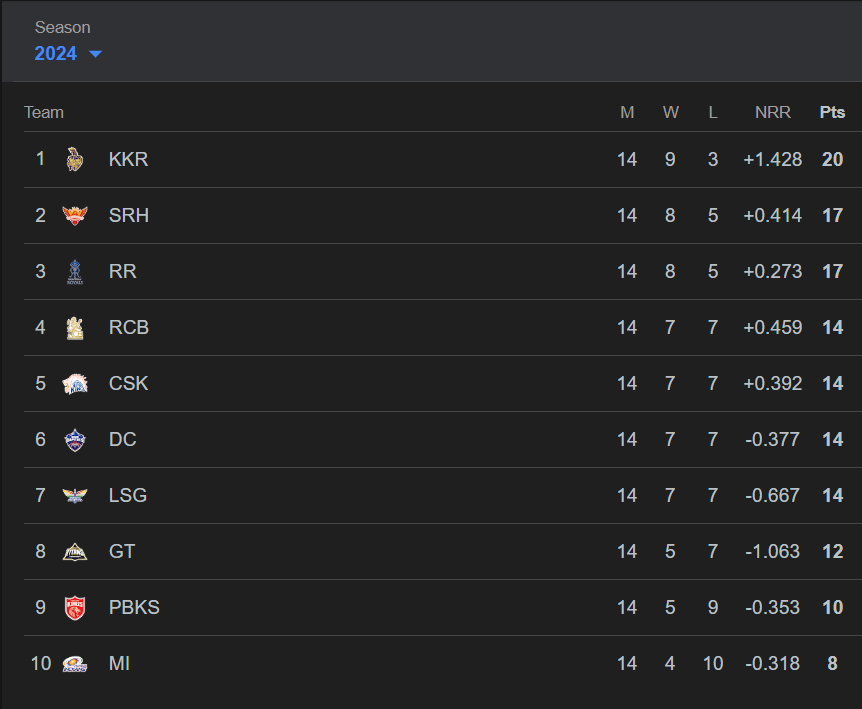

##Discussion
If we observe the new rankings of IPL Teams, Punjab kings which was in 9th as per traditional table is now qualified into playoffs. The main reason being that Punjab could have won more matches with larger margins or lost matches with less margin.

#<ins>A better ranking system</ins>
As the Massey's method considers only the point difference, we can include one more paramater to improve our rankings.

In IPL, two types of matches happen, home game and away game. In home game, home team will have say on what type of pitch they would like to play on. Pitch plays an crucial role on performance of team since it directly affects the team combination. For example, certain teams will have good quality spinner, they take leverage on the spinning tracks.

Hence this Home-Away aspect can be considered as one more criteria in scaling the point difference matrix.

* If a travelling team, wins in away game which is considered as challenging then they should be rewarded with more point difference. Similarly if a home team loses a match even after setting their desired pitch, they should be penalised .

* If home team wins or travelling lose it should be considered normal point difference liek previous case.

The modified eqaution will be :
$$
P_iR =
\begin{cases}
  \text{Q * 1.3} & \text{if travelling team (away) has won the match or home    team has lost the match} \\
  \text{Q} & \text{If home team has won the match or away team has lost the match}
\end{cases}
$$

where $i$ is $i^{th}$ match which is $i^{th}$ row of $P$ and $Q$ matrices.

1.3 is chosen



In [114]:
#Getting to know the all unique cities name where matches have been playe
print(match_data['city'].unique())
len(match_data['city'].unique())

['Chennai' 'Mohali' 'Kolkata' 'Jaipur' 'Ahmedabad' 'Bengaluru' 'Hyderabad'
 'Lucknow' 'Visakhapatnam' 'Mumbai' 'Delhi' 'Dharamsala' 'Guwahati']


13

In [115]:
#Assigning home ground for respective teams using the dictionary
home_teams = {'Royal Challengers Bengaluru': ['Bengaluru'],
              'Chennai Super Kings': ['Chennai'],
              'Rajasthan Royals': ['Jaipur','Guwahati'],
              'Delhi Capitals': ['Delhi','Visakhapatnam'],
              'Kolkata Knight Riders': ['Kolkata'],
              'Mumbai Indians': ['Mumbai'],
              'Punjab Kings': ['Mohali','Dharamsala'],
              'Sunrisers Hyderabad': ['Hyderabad'],
              'Gujarat Titans' : ['Ahmedabad'],
              'Lucknow Super Giants': ['Lucknow']
}


In [116]:
#Commented out, initally thought of modifiying the P matrix itself instead of Q

'''
for i, rows in match_data.iterrows():
  if rows['winner'] == rows['team1']:
    if rows['city'] in home_teams[rows['team1']]:
      P[i][np.where(teams == rows['team1'])[0][0]] = 1
      P[i][np.where(teams == rows['team2'])[0][0]] = -1

    else:
      P[i][np.where(teams == rows['team1'])[0][0]] = 1.3
      P[i][np.where(teams == rows['team2'])[0][0]] = -1.3

  else:
    if rows['city'] in home_teams[rows['team2']]:
      P[i][np.where(teams == rows['team2'])[0][0]] = 1
      P[i][np.where(teams == rows['team1'])[0][0]] = -1
    else:
      P[i][np.where(teams == rows['team2'])[0][0]] = 1.3
      P[i][np.where(teams == rows['team1'])[0][0]] = -1.3

print(P)
'''

"\nfor i, rows in match_data.iterrows():\n  if rows['winner'] == rows['team1']:\n    if rows['city'] in home_teams[rows['team1']]:\n      P[i][np.where(teams == rows['team1'])[0][0]] = 1\n      P[i][np.where(teams == rows['team2'])[0][0]] = -1\n\n    else:\n      P[i][np.where(teams == rows['team1'])[0][0]] = 1.3\n      P[i][np.where(teams == rows['team2'])[0][0]] = -1.3\n\n  else:\n    if rows['city'] in home_teams[rows['team2']]:\n      P[i][np.where(teams == rows['team2'])[0][0]] = 1\n      P[i][np.where(teams == rows['team1'])[0][0]] = -1\n    else:\n      P[i][np.where(teams == rows['team2'])[0][0]] = 1.3\n      P[i][np.where(teams == rows['team1'])[0][0]] = -1.3\n\nprint(P)\n"

##Repeating the same procedure as original case to solve the system of linear equations.

In [117]:
#Constructing M Matrix
# M = P^T P
M = np.matmul(P.T,P)
M.shape
print(M)

[[15. -1. -2. -2. -2. -2. -2. -2. -1. -1.]
 [-1. 14. -2. -2. -2. -1. -1. -1. -2. -2.]
 [-2. -2. 14. -1.  0. -1. -1. -3. -2. -2.]
 [-2. -2. -1. 15. -1. -2. -1. -2. -2. -2.]
 [-2. -2.  0. -1. 12. -2. -2. -1. -1. -1.]
 [-2. -1. -1. -2. -2. 14. -2. -2. -1. -1.]
 [-2. -1. -1. -1. -2. -2. 14. -2. -2. -1.]
 [-2. -1. -3. -2. -1. -2. -2. 16. -1. -2.]
 [-1. -2. -2. -2. -1. -1. -2. -1. 14. -2.]
 [-1. -2. -2. -2. -1. -1. -1. -2. -2. 14.]]


In [118]:
#Constructing R Matrix
for i, rows in match_data.iterrows():

  if rows['result'] == 'runs':
    B[i] = rows['result_margin'] / rows['target_runs']
  else:
    B[i] = rows['result_margin'] / 10

  if rows['winner'] == rows['team1']:
    if rows['city'] not in home_teams[rows['team1']]:
      B[i] = B[i]*1.3

  if rows['winner'] == rows['team2']:
    if rows['city'] not in home_teams[rows['team2']]:
      B[i] = B[i]*1.3

print(B)
B.shape


[0.6        0.4        0.01913876 0.10309278 0.03550296 0.4
 0.30434783 0.11151079 0.06451613 0.91       0.105      0.7
 0.10416667 0.78       0.2        0.5047619  0.39       0.6
 0.6        0.12340426 0.20121951 0.7        0.01420765 0.39
 0.7        0.78       0.39       0.8        0.12560386 0.11284722
 0.26       0.78       0.06062176 0.8        0.32621723 0.0044843
 0.39       0.9        0.78       0.01777778 0.21980676 1.04
 0.03875969 0.91       1.17       0.36619718 0.7        0.4
 0.91       0.0049505  0.18352941 0.4        0.21666667 0.53983051
 0.7        0.09009009 1.         0.32231405 0.15086207 0.11392405
 0.5        0.25       0.09090909 0.65       0.10883721 0.12328767
 0.4        1.04       0.52       0.26590909 1.04      ]


(71,)

In [119]:
#Constructing Q
Q = np.dot(P.T,B)
Q.shape
print(Q)

[-0.76192304 -0.4671962   3.85566894  2.62665924 -1.59698009  1.09118987
 -0.65550087 -1.24950022 -1.62877566 -1.21364196]


In [120]:
#Making last row of matrix M is zeroes
M[-1:] = np.ones((10))
print(M)

[[15. -1. -2. -2. -2. -2. -2. -2. -1. -1.]
 [-1. 14. -2. -2. -2. -1. -1. -1. -2. -2.]
 [-2. -2. 14. -1.  0. -1. -1. -3. -2. -2.]
 [-2. -2. -1. 15. -1. -2. -1. -2. -2. -2.]
 [-2. -2.  0. -1. 12. -2. -2. -1. -1. -1.]
 [-2. -1. -1. -2. -2. 14. -2. -2. -1. -1.]
 [-2. -1. -1. -1. -2. -2. 14. -2. -2. -1.]
 [-2. -1. -3. -2. -1. -2. -2. 16. -1. -2.]
 [-1. -2. -2. -2. -1. -1. -2. -1. 14. -2.]
 [ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.]]


In [121]:
#Making last row of Q is zeroes
Q[-1] = 0
print(Q)

[-0.76192304 -0.4671962   3.85566894  2.62665924 -1.59698009  1.09118987
 -0.65550087 -1.24950022 -1.62877566  0.        ]


In [122]:
#Solving the System of Linear Equations
R = np.linalg.solve(M,Q)
R

array([-0.03414049, -0.0247348 ,  0.24692466,  0.15212481, -0.14607533,
        0.0641125 , -0.0603118 , -0.04109956, -0.0919733 , -0.06482668])

In [123]:
ranks = np.argsort(-R)
order = np.empty_like(ranks)
order[ranks] = np.arange(1, len(R) + 1)

print(order)

[ 5  4  1  2 10  3  7  6  9  8]


In [124]:
rankings = dict(zip(teams,order))

In [125]:
team_ranking_dict = dict(sorted(rankings.items(), key=lambda x: x[1]))

team_ranking_dict

{'Kolkata Knight Riders': np.int64(1),
 'Rajasthan Royals': np.int64(2),
 'Punjab Kings': np.int64(3),
 'Delhi Capitals': np.int64(4),
 'Royal Challengers Bengaluru': np.int64(5),
 'Sunrisers Hyderabad': np.int64(6),
 'Chennai Super Kings': np.int64(7),
 'Mumbai Indians': np.int64(8),
 'Lucknow Super Giants': np.int64(9),
 'Gujarat Titans': np.int64(10)}

In [126]:
team_rankings2= pd.DataFrame(list(team_ranking_dict.items()), columns=['Team', 'Rank'])
team_rankings2


,Team,Rank
0,Kolkata Knight Riders,1
1,Rajasthan Royals,2
2,Punjab Kings,3
3,Delhi Capitals,4
4,Royal Challengers Bengaluru,5
5,Sunrisers Hyderabad,6
6,Chennai Super Kings,7
7,Mumbai Indians,8
8,Lucknow Super Giants,9
9,Gujarat Titans,10


##Discussion
If we see the new rankings, now one more new team, Delhi Capitals along with Punjab Kings has been qualified for play-offs. Both were eliminated in traditional points table.